In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import cartopy.crs as ccrs
import seaborn as sns
from matplotlib.patches import Patch
from cnmaps import get_adm_maps, draw_maps, clip_pcolormesh_by_map
# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']   # 黑体
# 解决负号显示异常
matplotlib.rcParams['axes.unicode_minus'] = False

PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP =  {
    '北京市': '北京',
    '天津市': '天津',
    '河北省': '河北',
    '山西省': '山西',
    '内蒙古自治区': '内蒙古',
    '辽宁省': '辽宁',
    '吉林省': '吉林',
    '黑龙江省': '黑龙江',
    '上海市': '上海',
    '江苏省': '江苏',
    '浙江省': '浙江',
    '安徽省': '安徽',
    '福建省': '福建',
    '江西省': '江西',
    '山东省': '山东',
    '河南省': '河南',
    '湖北省': '湖北',
    '湖南省': '湖南',
    '广东省': '广东',
    '广西壮族自治区': '广西',
    '海南省': '海南',
    '重庆市': '重庆',
    '四川省': '四川',
    '贵州省': '贵州',
    '云南省': '云南',
    '西藏自治区': '西藏',
    '陕西省': '陕西',
    '甘肃省': '甘肃',
    '青海省': '青海',
    '宁夏回族自治区': '宁夏',
    '新疆维吾尔自治区': '新疆',
    '台湾省': '台湾',
    '香港特别行政区': '香港',
}

PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP = {v:k for k,v in PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP.items()}

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from typing import Dict, Optional, Any

def plot_forecasting_results(
    data: pd.DataFrame,
    x: str = 'Year/Month',
    y: str = 'Cases',
    hue: str = 'Source',
    title: Optional[str] = None,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    user_style_dict: Optional[Dict[str, Dict[str, Any]]] = None,
    type_col: Optional[str] = 'Type',
    figsize: tuple = (12, 6),
    dpi: int = 300,
    date_interval: int = 6,
    save_path: Optional[str] = None,
    show: bool = True,
    ax: Optional[plt.Axes] = None,
    **kwargs
) -> plt.Axes:
    """
    绘制发表级别的传染病预测折线图（seaborn 风格）
    
    参数
    -------
    data : pandas.DataFrame
        输入数据，必须包含 x, y, hue 列
    x : str
        x 轴列名（通常是时间列）
    y : str
        y 轴列名（通常是病例数列）
    hue : str
        分组列名（用于区分不同线条，如 'Source'）
    title : str, optional
        图表标题。如果不提供，自动从数据中提取
    xlabel : str, optional
        x 轴标签。如果为 None，使用 x 列名
    ylabel : str, optional
        y 轴标签。如果为 None，使用 y 列名
    style_dict : dict, optional
        手动指定每条线的风格，格式：
        {
            'Real_Cases': {'color': '#2E86AB', 'linestyle': '-', 'linewidth': 2.5, 'marker': 'o', 'markersize': 6, 'label': 'Observed'},
            'CNN_Prediction': {'color': '#A23B72', 'linestyle': '--', 'linewidth': 2.5, 'marker': 's', 'markersize': 6, 'label': 'CNN Prediction'},
        }
        如果为 None，则自动生成风格
    type_col : str, optional
        数据类型列名（如 'Type'，用于标注 Train/Val/Test）
    figsize : tuple
        图形大小（仅当 ax 为 None 时有效）
    dpi : int
        分辨率（仅当 ax 为 None 时有效）
    date_interval : int
        x 轴日期刻度间隔（月）。如果为 None，使用自动定位器
    save_path : str, optional
        保存路径（支持 .png, .pdf）（仅当 ax 为 None 时有效）
    show : bool
        是否显示图形（仅当 ax 为 None 时有效）
    ax : plt.Axes, optional
        传入现有的 Axes 对象。如果提供，则在指定 axes 上绘图，并返回该 axes
    **kwargs : dict
        其他传递给 ax.plot() 的参数
    
    返回
    -------
    ax : matplotlib.axes.Axes
        图形轴对象（类似 seaborn 的返回风格）
    """
    
    # 设置发表级别的绘图样式（仅当创建新图时）
    if ax is None:
        plt.style.use('seaborn-v0_8-whitegrid')
        sns.set_context("paper", rc={"font.size":12, "axes.titlesize":14, "axes.labelsize":12})
    
    # 确保 x 列是 datetime 格式
    if not pd.api.types.is_datetime64_any_dtype(data[x]):
        data = data.copy()
        data[x] = pd.to_datetime(data[x])
    
    # 如果没有提供 ax，创建新的图形和轴
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # 获取所有 hue 类别
    hue_categories = data[hue].unique()
    
    # 如果没有提供 style_dict，自动生成
    
    # 默认调色板
    palette = sns.color_palette("tab10", n_colors=len(hue_categories))
    linestyles = ['-', '--', '-.', ':'] * (len(hue_categories) // 4 + 1)
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p'] * (len(hue_categories) // 8 + 1)
    
    style_dict = {}
    for i, category in enumerate(hue_categories):
        style_dict[category] = {
            'color': palette[i],
            'linestyle': linestyles[i],
            'linewidth': 2.5,
            'marker': markers[i],
            'markersize': 4,
            'label': category,
            'alpha': 0.8
        }
    if user_style_dict is not None: 
        for key, value in user_style_dict.items():
            style_dict[key].update(value)

    # 绘制每条线
    for category in hue_categories:
        subset = data[data[hue] == category]
        
        # 获取该类别的风格
        style = style_dict.get(category, {})
        
        # 绘制线条
        ax.plot(
            subset[x], 
            subset[y], 
            color=style.get('color', None),
            linestyle=style.get('linestyle', '-'),
            linewidth=style.get('linewidth', 2.5),
            marker=style.get('marker', None),
            markersize=style.get('markersize', 6),
            label=style.get('label', category),
            alpha=style.get('alpha', 0.8),
            **kwargs
        )
    
    # 添加垂直阴影标注训练/验证/测试集
    if type_col is not None and type_col in data.columns:
        type_colors = {'Train': '#E8F4F8', 'Val': '#FFF4E6', 'Test': '#FCE4EC'}
        for type_name, color in type_colors.items():
            type_data = data[data[type_col] == type_name]
            if not type_data.empty:
                ax.axvspan(
                    type_data[x].min(), 
                    type_data[x].max(), 
                    alpha=0.2, 
                    color=color, 
                    label=f'{type_name}ing Period'
                )
    
    # 自定义坐标轴
    ax.set_xlabel(xlabel if xlabel is not None else x, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel if ylabel is not None else y, fontsize=14, fontweight='bold')
    
    # 设置标题
    if title is None:
        title = 'Forecasting Results'
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # 优化图例
    legend = ax.legend(loc='upper left', fontsize=12, framealpha=0.95, edgecolor='black')
    legend.get_frame().set_linewidth(1.5)
    
    # 设置网格
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.minorticks_on()
    
    # 优化刻度
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.5)
    ax.tick_params(axis='both', which='minor', labelsize=10, length=4, width=1)
    
    # # 优化 x 轴日期显示
    # if isinstance(date_interval, int) and date_interval > 0:
    #     ax.xaxis.set_major_locator(mdates.MonthLocator(interval=date_interval))
    #     ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # else:
    #     # 使用自动日期定位器
    #     locator = mdates.AutoDateLocator()
    #     ax.xaxis.set_major_locator(locator)
    #     ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
    
    # 设置 x 轴范围，确保不超出数据范围
    x_min = data[x].min()
    x_max = data[x].max()
    margin = pd.DateOffset(months=1)
    ax.set_xlim(x_min - margin, x_max + margin)
    
    # 旋转 x 轴标签
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 去除边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # 调整布局（仅当创建新图时）
    if ax.get_figure() is not None and ax.get_figure() is plt.gcf():
        plt.tight_layout()
    
    # 保存图片（仅当创建新图时）
    if save_path is not None and ax is None:
        if save_path.endswith('.png'):
            plt.savefig(save_path, dpi=600, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
        elif save_path.endswith('.pdf'):
            plt.savefig(save_path, dpi=600, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
        else:
            plt.savefig(save_path, dpi=600, bbox_inches='tight')
    
    # 显示图形（仅当创建新图时）
    if show and ax is None:
        plt.show()
    
    return ax


In [2]:
province_maps = get_adm_maps(level="省", record="all")
import geopandas as gpd

gdf_map = gpd.GeoDataFrame(province_maps)
gdf_map.head(3)

,country,province,city,district,level,source,kind,geometry,longitude,latitude,国家,省/直辖市,市,区/县,级别,来源,类型,经度,纬度
0,中华人民共和国,北京市,None,None,省,高德,陆地,"MULTIPOLYGON (((116.7835 40.03128, 116.78414 4...",116.412625,40.185628,中华人民共和国,北京市,None,None,省,高德,陆地,116.412625,40.185628
1,中华人民共和国,天津市,None,None,省,高德,陆地,"MULTIPOLYGON (((117.8411 39.40598, 117.84127 3...",117.341601,39.283780,中华人民共和国,天津市,None,None,省,高德,陆地,117.341601,39.283780
2,中华人民共和国,河北省,None,None,省,高德,陆地,"MULTIPOLYGON (((118.26655 38.97998, 118.26406 ...",116.143248,39.545755,中华人民共和国,河北省,None,None,省,高德,陆地,116.143248,39.545755


In [3]:

df_all = pd.read_feather("Dengue.feather")
df_all['province'] = df_all['City'].replace(PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP)
df_all



,Time,CNNLSTMForecaster,Labels,City,Dataset,CNNForecaster,DLinearForecaster,LSTMForecaster,MLPForecaster,ResNetForecaster,TCNForecaster,TransformerForecaster,AutoformerForecaster,TimesNetForecaster,XGBSingleForecaster,province
0,2005-01-01,-23.729261,0.0,江西,train,-12.565220,-26.217857,-21.672554,-12.551907,-20.450478,-13.253731,-17.236217,-12.854452,-23.756239,-0.004233,江西省
1,2005-02-01,-24.912880,0.0,江西,train,-12.453150,-18.181519,-29.758297,-11.644766,-39.346741,-12.492916,-16.921816,-15.672018,-24.761414,-0.146540,江西省
2,2005-03-01,-23.615232,0.0,江西,train,-13.482731,-29.491089,-23.313293,-12.542044,-41.351574,-16.044102,-16.728395,-13.632906,-25.459473,0.057235,江西省
3,2005-04-01,-16.010069,0.0,江西,train,-12.565220,-29.656433,-28.960735,-12.551907,-19.052019,-13.253731,-11.154093,-12.920635,-22.945917,-0.029545,江西省
4,2005-05-01,-17.120281,0.0,江西,train,-12.453150,-24.433495,-26.937859,-11.644766,-38.081421,-12.492916,-12.138878,-15.757113,-20.853926,-0.125485,江西省
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5854,2020-05-01,-15.152290,0.0,西藏,test,-12.453150,9.763773,-15.155693,-11.644766,-34.356895,-12.492916,-18.020748,-15.656260,-31.681263,0.234179,西藏自治区
5855,2020-06-01,-12.501762,0.0,西藏,test,-13.482731,3.468175,-9.986752,-12.542044,-14.911768,-16.044102,-14.951859,-13.576178,-32.363079,0.894556,西藏自治区
5856,2020-07-01,-14.224161,0.0,西藏,test,-12.565220,28.857697,-26.218552,-12.551907,18.901398,-13.253731,-12.730844,-12.958456,-28.253147,9.329739,西藏自治区
5857,2020-08-01,-8.608046,0.0,西藏,test,-12.453150,63.267071,-7.780233,-11.644766,12.008417,-12.492916,-13.819777,-15.694078,-28.080971,574.711792,西藏自治区


## 时间图

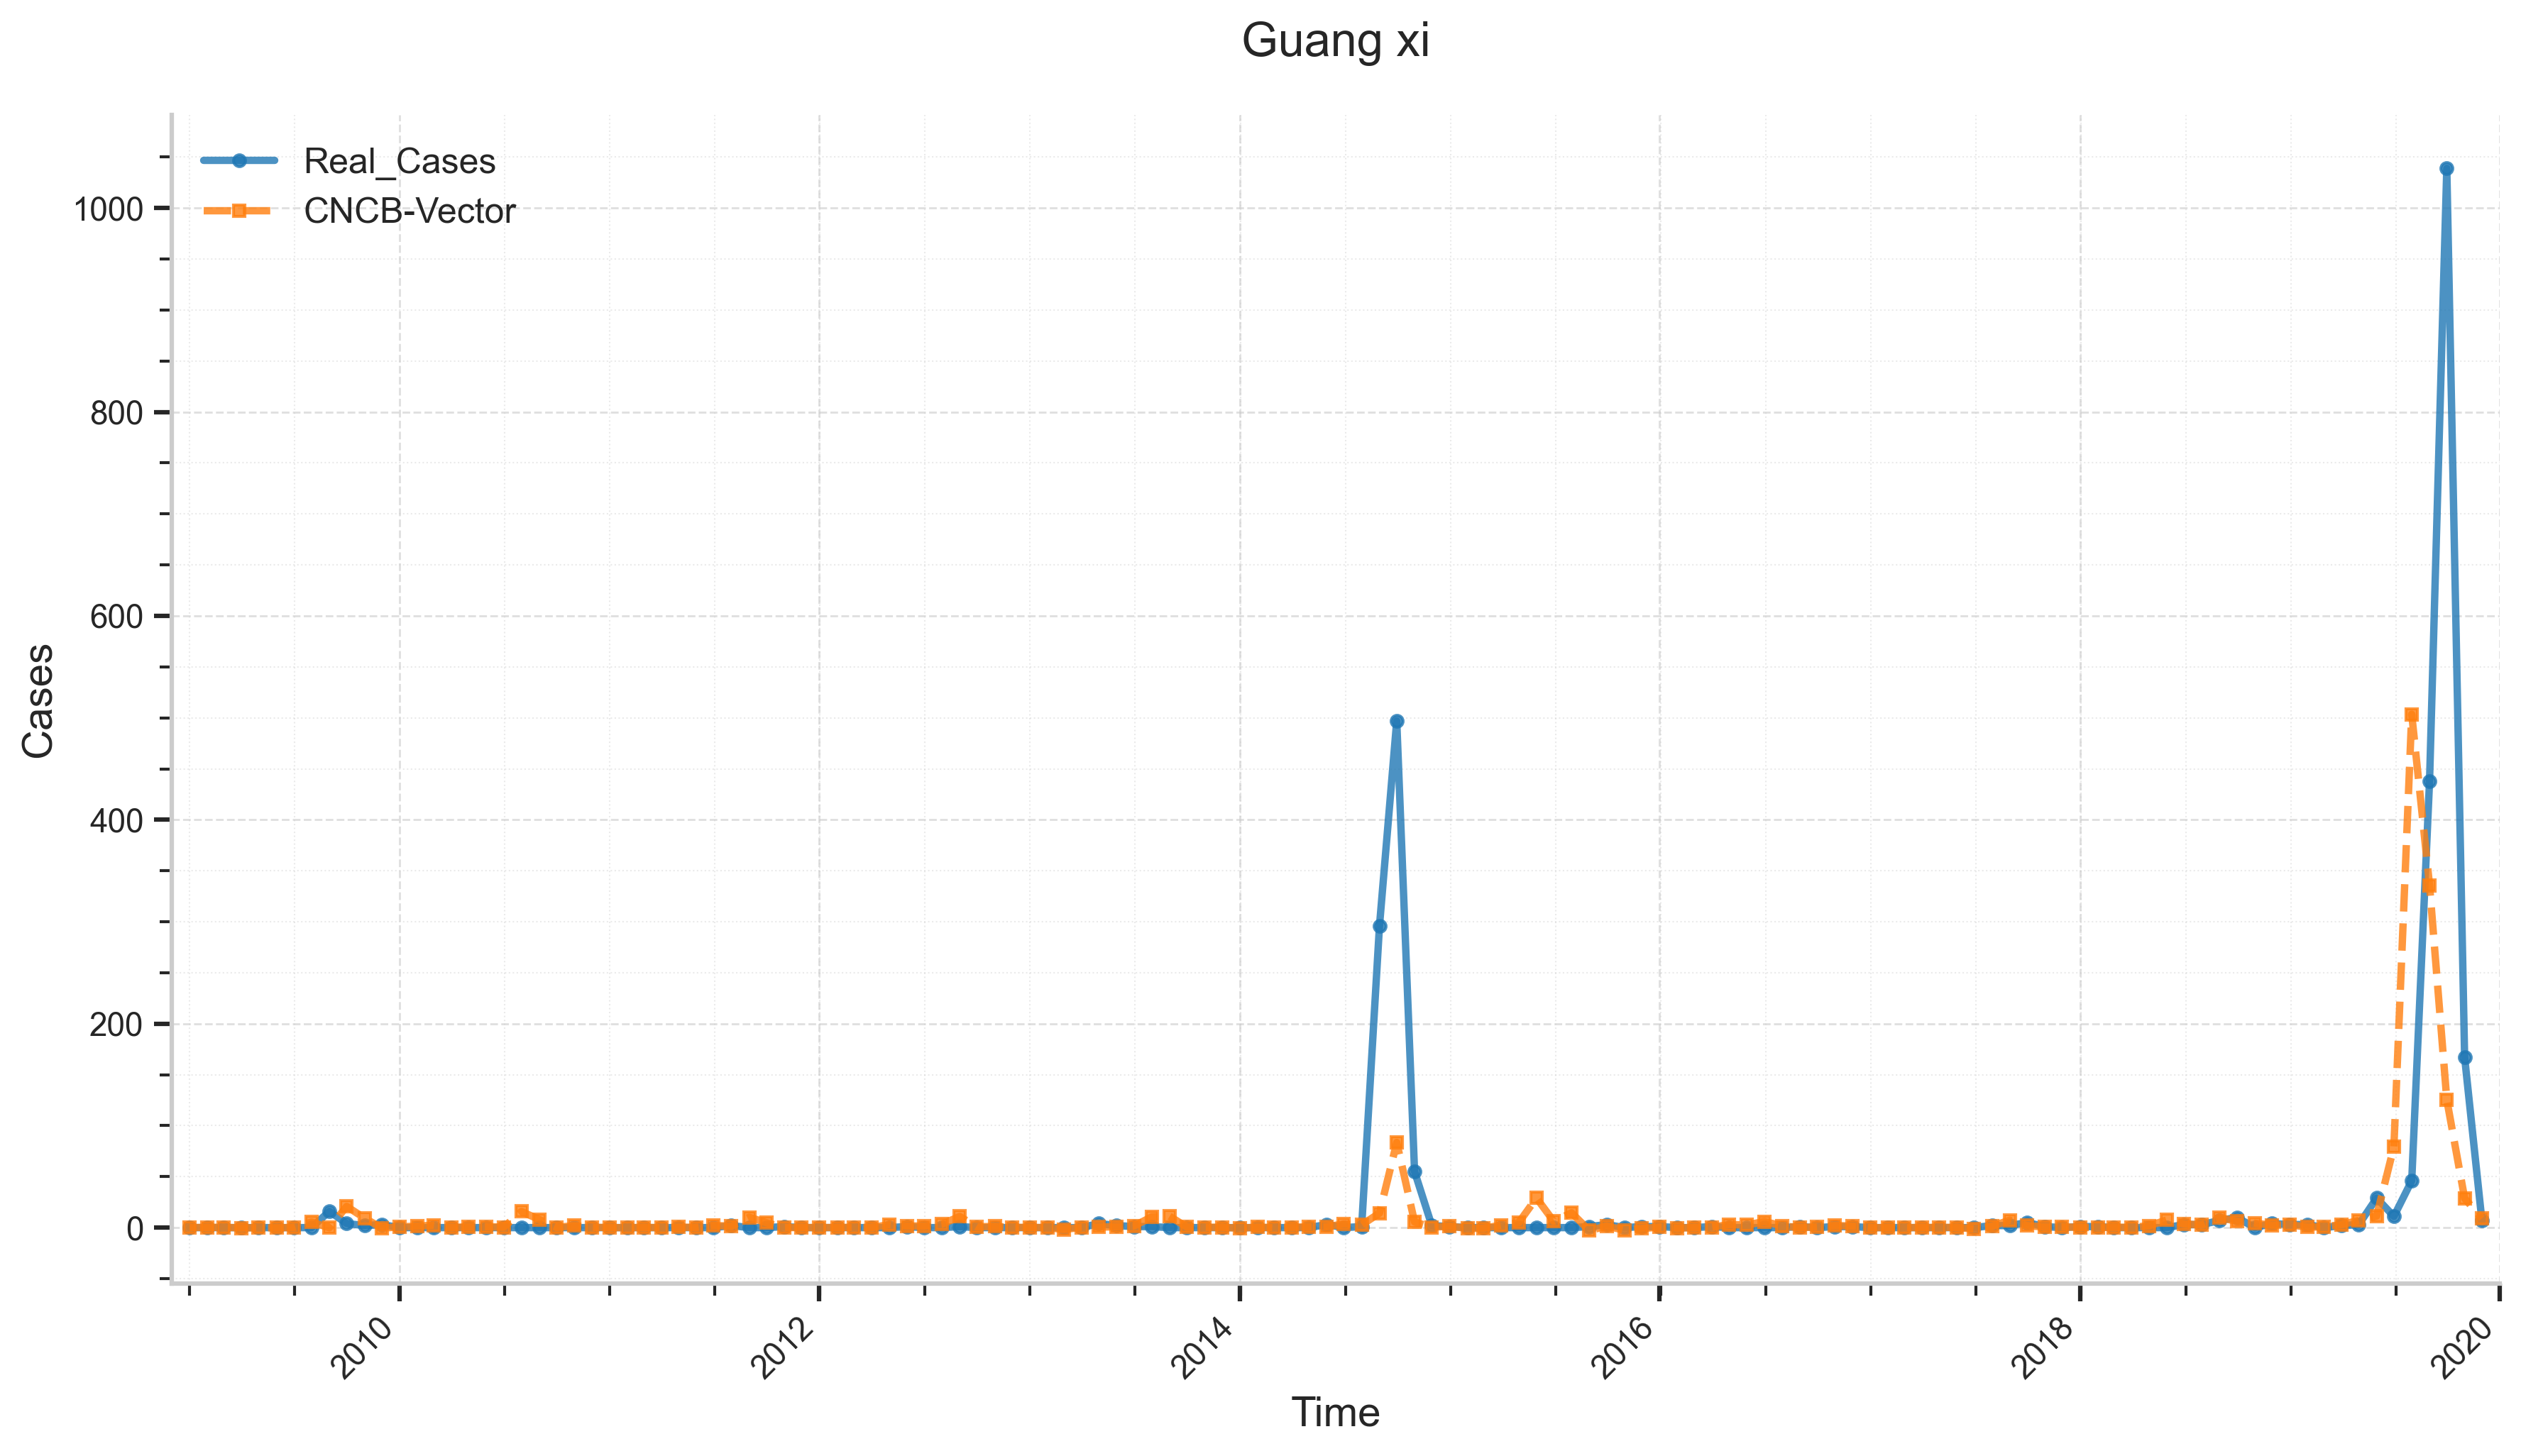

In [61]:
time_col = 'Time'
Case_col = 'Labels'
plt_data = df_all.query("City =='广西'")
plt_data = plt_data[(plt_data["Time"].dt.year > 2008) & (plt_data["Time"].dt.year < 2020)]
plt_data = plt_data[[time_col,Case_col, 'XGBSingleForecaster']].rename(columns={Case_col:"Real_Cases", "XGBSingleForecaster":"CNCB-Vector"}).melt(id_vars = time_col, var_name = 'Source', value_name = 'Cases')

fig = plot_forecasting_results(
    data=plt_data,
    x=time_col,
    y='Cases',
    hue='Source',
    title = 'Guang xi',
    date_interval='auto',
    figsize=(12,7)
    # user_style_dict=style_dict
)


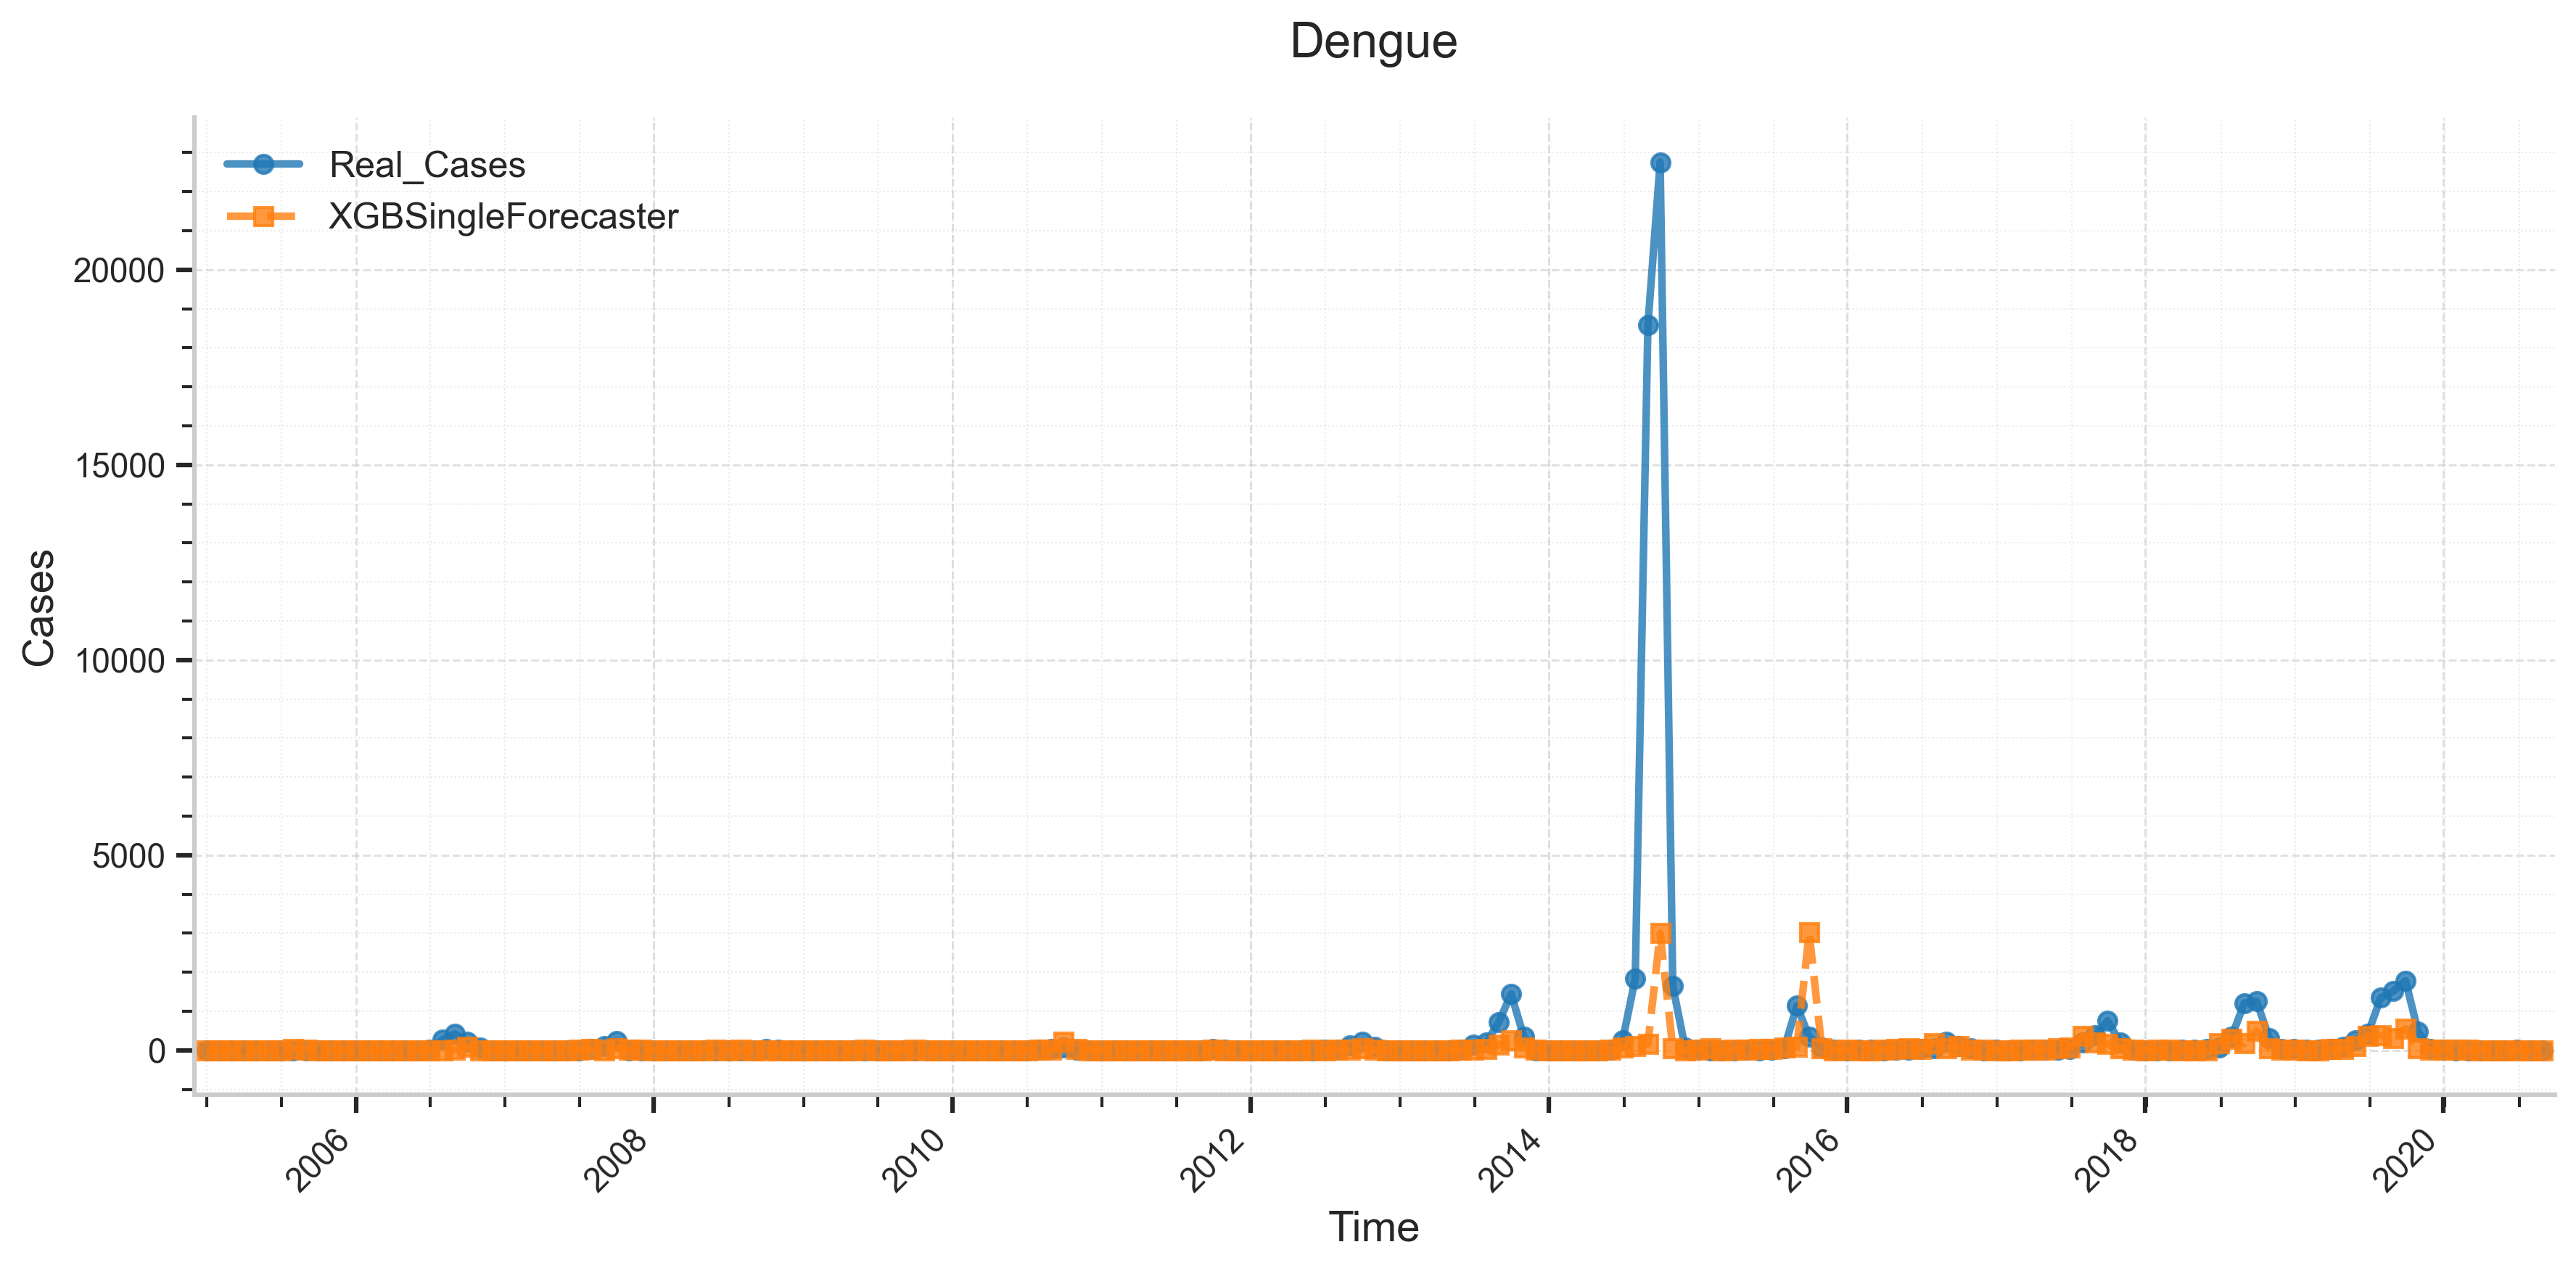

In [ ]:



fig = plot_forecasting_results(
    data=plt_data,
    x=time_col,
    y='Cases',
    hue='Source',
    title = 'Dengue',
    date_interval='auto',
    # user_style_dict=style_dict
)


## 评估爆发

In [ ]:
import pandas as pd
import numpy as np


def add_seasonal_moving_percentile_outbreak(
    df,
    time_col="Time",
    city_col="City",
    label_col="Labels",
    window=1,
    percentile=75,
    min_history=3,
    exclude_current_year=True,
):
    """
    使用 seasonal moving percentile threshold 定义 outbreak。

    对每个 city-year-month：
        1. 取同一个城市的数据；
        2. 取目标月份 ± window 的月份；
        3. 如果 exclude_current_year=True，则只使用目标年份之前的数据；
        4. 用这些历史 Labels 计算指定 percentile；
        5. 如果当前 Labels > threshold，则 outbreak = 1，否则 outbreak = 0；
        6. 如果 threshold 是 NaN，则 outbreak = NaN。

    参数
    ----
    df : pd.DataFrame
        原始数据。

    time_col : str
        时间列名，例如 "Time"。

    city_col : str
        城市/省份列名，例如 "City"。

    label_col : str
        实际发病数列名，例如 "Labels"。

    window : int
        季节移动窗口。
        window=0：只使用历史同月；
        window=1：使用目标月份前后 1 个月；
        window=2：使用目标月份前后 2 个月。

    percentile : float or int
        分位数，范围 0–100。
        例如 percentile=75 表示 P75。

    min_history : int
        计算阈值所需的最少历史样本数。
        如果历史样本数不足，则 threshold = NaN。

    exclude_current_year : bool
        是否排除当前年份。
        True 表示只使用当前年份之前的数据，适合真实预警；
        False 表示排除当前 city-year-month 本身，但可使用其他年份和同年其他月份。
    """

    if not (0 <= percentile <= 100):
        raise ValueError("percentile 必须在 0 到 100 之间。")

    data = df.copy()
    data[time_col] = pd.to_datetime(data[time_col])

    data["_year"] = data[time_col].dt.year
    data["_month"] = data[time_col].dt.month

    threshold_col = f"seasonal_moving_P{percentile:g}"

    def month_in_window(month_series, target_month, window):
        """
        循环月份窗口。
        例如：
        target_month=1, window=1 -> 12, 1, 2
        target_month=12, window=1 -> 11, 12, 1
        """
        diff = (month_series - target_month).abs()
        circular_diff = np.minimum(diff, 12 - diff)
        return circular_diff <= window

    combos = (
        data[[city_col, time_col, "_year", "_month"]]
        .drop_duplicates()
        .sort_values([city_col, time_col])
        .reset_index(drop=True)
    )

    cutoff_records = []

    for _, row in combos.iterrows():
        city = row[city_col]
        time_value = row[time_col]
        year = row["_year"]
        month = row["_month"]

        hist = data[data[city_col] == city].copy()

        if exclude_current_year:
            hist = hist[hist["_year"] < year].copy()
        else:
            hist = hist[
                ~(
                    (hist["_year"] == year) &
                    (hist["_month"] == month)
                )
            ].copy()

        hist = hist[
            month_in_window(hist["_month"], month, window)
        ].copy()

        if len(hist) < min_history:
            threshold = np.nan
        else:
            threshold = hist[label_col].quantile(
                percentile / 100,
                interpolation="linear"
            )

        cutoff_records.append({
            city_col: city,
            time_col: time_value,
            threshold_col: threshold,
            "history_n": len(hist)
        })

    cutoff_table = pd.DataFrame(cutoff_records)

    # 合并阈值回原数据
    out = data.merge(
        cutoff_table,
        on=[city_col, time_col],
        how="left"
    )

    # 是否爆发：label > threshold
    outbreak_col = f"outbreak_gt_P{percentile:g}"

    out[outbreak_col] = np.where(
        out[threshold_col].isna(),
        np.nan,
        (out[label_col] > out[threshold_col]).astype(int)
    )

    # 返回指定字段
    result = out[
        [
            time_col,
            city_col,
            label_col,
            threshold_col,
            outbreak_col,
            "history_n"
        ]
    ].copy()

    return result



import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)


# ========== 5. 定义评价函数 ==========
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # 防止除0
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

    return rmse, mae, mape


import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

def evaluate_outbreak_detection(y_true, y_pred, cutoff=1.0):
    """
    y_true: 连续真实值
    y_pred: 连续预测值
    cutoff: 对 y_true 定义“是否爆发”的固定阈值

    逻辑：
    1. y_true >= cutoff -> 真实二分类标签
    2. 用 y_pred 作为连续得分，计算 ROC
    3. 用 Youden index = TPR - FPR 选最优阈值
    4. 用这个最优阈值把 y_pred 转成二分类
    5. 输出 precision / recall / f1 / accuracy / AUC / 最优阈值
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # 1) 真实标签二值化
    y_true_bin = (y_true >= cutoff).astype(int)

    # 默认值
    best_cutoff_pred = np.nan
    auc = np.nan
    precision = np.nan
    recall = np.nan
    f1 = np.nan
    accuracy = np.nan
    outbreak_count_true = int(y_true_bin.sum())
    outbreak_count_pred = np.nan

    # 若真实标签只有一个类别，AUC/ROC 无法定义
    if len(np.unique(y_true_bin)) < 2:
        # 可以退化为直接用 cutoff 对 y_pred 二值化，方便至少给出部分指标
        y_pred_bin = (y_pred >= cutoff).astype(int)

        precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        accuracy = accuracy_score(y_true_bin, y_pred_bin)
        outbreak_count_pred = int(y_pred_bin.sum())
        best_cutoff_pred = cutoff

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            "auc": auc,
            "best_cutoff_pred": best_cutoff_pred,
            "outbreak_count_true": outbreak_count_true,
            "outbreak_count_pred": outbreak_count_pred
        }

    # 2) AUC
    auc = roc_auc_score(y_true_bin, y_pred)

    # 3) ROC + Youden index
    fpr, tpr, thresholds = roc_curve(y_true_bin, y_pred)
    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)
    best_cutoff_pred = thresholds[best_idx]

    # 4) 用最优阈值二值化预测
    y_pred_bin = (y_pred >= best_cutoff_pred).astype(int)

    # 5) 分类指标
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    outbreak_count_pred = int(y_pred_bin.sum())

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "auc": auc,
        "best_cutoff_pred": best_cutoff_pred,
        "outbreak_count_true": outbreak_count_true,
        "outbreak_count_pred": outbreak_count_pred
    }

In [18]:
df_out = add_seasonal_moving_percentile_outbreak(
    df_all,
    time_col="Time",
    city_col="City",
    label_col="Labels",
    window=1,
    percentile=75,
    min_history=15,
    exclude_current_year=True
)

df_out.head()


,Time,City,Labels,seasonal_moving_P75,outbreak_gt_P75,history_n
0,2005-01-01,江西,0.0,NaN,NaN,0
1,2005-02-01,江西,0.0,NaN,NaN,0
2,2005-03-01,江西,0.0,NaN,NaN,0
3,2005-04-01,江西,0.0,NaN,NaN,0
4,2005-05-01,江西,0.0,NaN,NaN,0


In [19]:
df_out.query("City =='广东'").head(30)

,Time,City,Labels,seasonal_moving_P75,outbreak_gt_P75,history_n
5481,2005-01-01,广东,0.0,NaN,NaN,0
5482,2005-02-01,广东,0.0,NaN,NaN,0
5483,2005-03-01,广东,0.0,NaN,NaN,0
5484,2005-04-01,广东,0.0,NaN,NaN,0
5485,2005-05-01,广东,0.0,NaN,NaN,0
5486,2005-06-01,广东,0.0,NaN,NaN,0
5487,2005-07-01,广东,2.0,NaN,NaN,0
5488,2005-08-01,广东,0.0,NaN,NaN,0
5489,2005-09-01,广东,3.0,NaN,NaN,0
5490,2005-10-01,广东,0.0,NaN,NaN,0


In [23]:
for_breakout_df = df_all[['Time','City','Dataset','XGBSingleForecaster']].merge(df_out).dropna(subset = ['seasonal_moving_P75']) # drop first 5 yr
for_breakout_df

,Time,City,Dataset,XGBSingleForecaster,Labels,seasonal_moving_P75,outbreak_gt_P75,history_n
60,2010-01-01,江西,train,0.308545,1.0,0.0,1.0,15
61,2010-02-01,江西,train,-0.042303,0.0,0.0,0.0,15
62,2010-03-01,江西,train,-0.351165,0.0,0.0,0.0,15
63,2010-04-01,江西,train,-0.022956,0.0,0.0,0.0,15
64,2010-05-01,江西,train,0.449971,1.0,0.0,1.0,15
...,...,...,...,...,...,...,...,...
5854,2020-05-01,西藏,test,0.234179,0.0,0.0,0.0,45
5855,2020-06-01,西藏,test,0.894556,0.0,0.0,0.0,45
5856,2020-07-01,西藏,test,9.329739,0.0,0.0,0.0,45
5857,2020-08-01,西藏,test,574.711792,0.0,0.0,0.0,45


In [29]:


# ========== 6. 按省份评估 ==========
results = []
df_test = for_breakout_df.copy()
for city, group in df_test.groupby("City"):
    y_true_breakout = group["outbreak_gt_P75"].values
    y_true = group['Labels'].values
    for model in ['XGBSingleForecaster']:
        y_pred = group[model].values

        # 回归指标
        rmse, mae, mape = evaluate_regression(y_true, y_pred)

        # 爆发检测指标
        outbreak_metrics = evaluate_outbreak_detection(
            y_true_breakout, y_pred, cutoff=1
        )

        results.append({
            "City": city,
            "Model": model,
            "RMSE": rmse,
            "MAE": mae,
            # "MAPE": mape,
            "Precision_Outbreak": outbreak_metrics["precision"],
            "Recall_Outbreak": outbreak_metrics["recall"],
            "F1_Outbreak": outbreak_metrics["f1"],
            "Accuracy_Outbreak": outbreak_metrics["accuracy"],
            "AUC_Outbreak": outbreak_metrics["auc"],
            "Pred_Cutoff_Youden": outbreak_metrics["best_cutoff_pred"],
            "True_Outbreak_Count": outbreak_metrics["outbreak_count_true"],
            "Pred_Outbreak_Count": outbreak_metrics["outbreak_count_pred"]
        })
# 转为DataFrame
results_df = pd.DataFrame(results)
# for_breakout_df[['City','Dataset']]
results_df

,City,Model,RMSE,MAE,Precision_Outbreak,Recall_Outbreak,F1_Outbreak,Accuracy_Outbreak,AUC_Outbreak,Pred_Cutoff_Youden,True_Outbreak_Count,Pred_Outbreak_Count
0,上海,XGBSingleForecaster,6.736821,3.019573,0.511628,0.550000,0.530120,0.697674,0.637360,1.498926,40,43
1,云南,XGBSingleForecaster,1.196207,0.873125,0.914286,0.800000,0.853333,0.829457,0.873724,2.709530,80,70
2,内蒙古,XGBSingleForecaster,5.052913,0.602329,0.075758,1.000000,0.140845,0.527132,0.695161,0.044078,5,66
3,北京,XGBSingleForecaster,5.439391,2.735925,0.483871,0.545455,0.512821,0.558140,0.539803,1.639430,55,62
4,吉林,XGBSingleForecaster,0.579694,0.277022,0.500000,0.250000,0.333333,0.906977,0.522080,0.759073,12,6
5,四川,XGBSingleForecaster,185.953308,39.727692,0.705128,0.797101,0.748299,0.713178,0.722947,1.356992,69,78
6,天津,XGBSingleForecaster,3.415516,1.613731,0.241379,0.875000,0.378378,0.643411,0.702987,0.734535,16,58
7,宁夏,XGBSingleForecaster,0.601066,0.321691,0.135135,1.000000,0.238095,0.751938,0.804839,0.268579,5,37
8,安徽,XGBSingleForecaster,2.886468,1.372296,0.673913,0.645833,0.659574,0.751938,0.755916,0.973701,48,46
9,山东,XGBSingleForecaster,5.186799,1.905714,0.655172,0.678571,0.666667,0.705426,0.743640,0.925455,56,58


In [36]:
for_breakout_df[['City','Dataset']].drop_duplicates()

,City,Dataset
60,江西,train
249,湖南,train
438,贵州,train
627,云南,train
816,浙江,train
1005,海南,train
1194,福建,train
1383,江苏,train
1572,河北,train
1761,河南,train


In [34]:
results_df.sort_values("AUC_Outbreak",ascending=False)[['City','AUC_Outbreak','Precision_Outbreak','Recall_Outbreak','F1_Outbreak']].round(3).reset_index(drop=True)

,City,AUC_Outbreak,Precision_Outbreak,Recall_Outbreak,F1_Outbreak
0,浙江,0.963,0.942,0.890,0.915
1,海南,0.928,0.794,0.871,0.831
2,湖南,0.898,0.729,0.911,0.810
3,重庆,0.892,0.840,0.792,0.816
4,江苏,0.891,0.900,0.738,0.811
5,河南,0.890,0.750,0.871,0.806
6,贵州,0.889,0.373,0.957,0.537
7,福建,0.885,0.929,0.722,0.812
8,云南,0.874,0.914,0.800,0.853
9,湖北,0.872,0.649,0.943,0.769


In [79]:
youden_cutoff_df = results_df[['City', 'Pred_Cutoff_Youden']].copy()
youden_cutoff_df['province'] = results_df['City'].replace(PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP)
del youden_cutoff_df['City']
youden_cutoff_df

,Pred_Cutoff_Youden,province
0,1.498926,上海市
1,2.709530,云南省
2,0.044078,内蒙古自治区
3,1.639430,北京市
4,0.759073,吉林省
5,1.356992,四川省
6,0.734535,天津市
7,0.268579,宁夏回族自治区
8,0.973701,安徽省
9,0.925455,山东省


## 绘制中国部分预警图

In [102]:
df_out_for_merge = df_out[['City','outbreak_gt_P75','Time']].copy()
df_out_for_merge['province'] = df_out_for_merge['City'].replace(PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP)
df_out_for_merge

,City,outbreak_gt_P75,Time,province
0,江西,NaN,2005-01-01,江西省
1,江西,NaN,2005-02-01,江西省
2,江西,NaN,2005-03-01,江西省
3,江西,NaN,2005-04-01,江西省
4,江西,NaN,2005-05-01,江西省
...,...,...,...,...
5854,西藏,0.0,2020-05-01,西藏自治区
5855,西藏,0.0,2020-06-01,西藏自治区
5856,西藏,0.0,2020-07-01,西藏自治区
5857,西藏,0.0,2020-08-01,西藏自治区


In [140]:
df_all_with_score = df_all.copy().merge(youden_cutoff_df).merge(df_out_for_merge).dropna(subset=['outbreak_gt_P75'])
df_all_with_score['is_breakout'] = (df_all_with_score['XGBSingleForecaster'] >=   df_all_with_score['Pred_Cutoff_Youden']   ).astype(int)
df_all_with_score['warning_level'] = df_all_with_score['is_breakout'].replace({1:"High risk", 0:"No risk"}).astype("category")
df_all_with_score['warning_level_by_outbreak_gt_P75'] = df_all_with_score['outbreak_gt_P75'].replace({1:"High risk", 0:"No risk"}).astype("category")

df_all_with_score

,Time,CNNLSTMForecaster,Labels,City,Dataset,CNNForecaster,DLinearForecaster,LSTMForecaster,MLPForecaster,ResNetForecaster,...,TransformerForecaster,AutoformerForecaster,TimesNetForecaster,XGBSingleForecaster,province,Pred_Cutoff_Youden,outbreak_gt_P75,is_breakout,warning_level,warning_level_by_outbreak_gt_P75
60,2010-01-01,-28.577679,1.0,江西,train,-12.565220,-20.183483,-18.028214,-12.551907,-18.402262,...,-12.793955,-12.952152,-16.581873,0.308545,江西省,0.615952,1.0,0,No risk,High risk
61,2010-02-01,-35.262859,0.0,江西,train,-12.453150,-19.190624,-17.284252,-11.644766,-39.271286,...,-14.086277,-15.694078,-17.210056,-0.042303,江西省,0.615952,0.0,0,No risk,No risk
62,2010-03-01,-35.479118,0.0,江西,train,-13.482731,-21.547544,-12.185745,-12.542044,-43.625637,...,-10.513210,-13.664421,-17.606937,-0.351165,江西省,0.615952,0.0,0,No risk,No risk
63,2010-04-01,-27.893715,0.0,江西,train,-12.565220,-15.058697,-20.006420,-12.551907,-15.813362,...,-10.387850,-12.920635,-17.695690,-0.022956,江西省,0.615952,0.0,0,No risk,No risk
64,2010-05-01,-32.693645,1.0,江西,train,-12.453150,-12.960777,-29.453865,-11.644766,-35.557938,...,-12.165527,-15.709839,-14.279333,0.449971,江西省,0.615952,1.0,0,No risk,High risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5854,2020-05-01,-15.152290,0.0,西藏,test,-12.453150,9.763773,-15.155693,-11.644766,-34.356895,...,-18.020748,-15.656260,-31.681263,0.234179,西藏自治区,1.000000,0.0,0,No risk,No risk
5855,2020-06-01,-12.501762,0.0,西藏,test,-13.482731,3.468175,-9.986752,-12.542044,-14.911768,...,-14.951859,-13.576178,-32.363079,0.894556,西藏自治区,1.000000,0.0,0,No risk,No risk
5856,2020-07-01,-14.224161,0.0,西藏,test,-12.565220,28.857697,-26.218552,-12.551907,18.901398,...,-12.730844,-12.958456,-28.253147,9.329739,西藏自治区,1.000000,0.0,1,High risk,No risk
5857,2020-08-01,-8.608046,0.0,西藏,test,-12.453150,63.267071,-7.780233,-11.644766,12.008417,...,-13.819777,-15.694078,-28.080971,574.711792,西藏自治区,1.000000,0.0,1,High risk,No risk


In [147]:
# metric_df_breakout_by_month = df_all_with_score.groupby("Time").apply(lambda x:        pd.Series(evaluate_outbreak_detection(
#             x['is_breakout'], x['outbreak_gt_P75'], cutoff=1
#         )))
# metric_df_breakout_by_month

# 改成 for 循环，先 dropna 再计算
results = []
for time_val, group in df_all_with_score.groupby("Time"):
    group = group.dropna(subset=["is_breakout", "outbreak_gt_P75"])
    if len(group) == 0:
        continue
    metrics = evaluate_outbreak_detection(
        group['is_breakout'], group['outbreak_gt_P75'], cutoff=0.5
    )
    metrics['Time'] = time_val
    results.append(metrics)

metric_df_breakout_by_month = pd.DataFrame(results)
metric_df_breakout_by_month


,precision,recall,f1,accuracy,auc,best_cutoff_pred,outbreak_count_true,outbreak_count_pred,Time
0,0.000000,0.000000,0.000000,0.967742,0.466667,inf,1,0,2010-01-01
1,0.000000,0.000000,0.000000,0.935484,0.500000,inf,2,0,2010-02-01
2,0.000000,0.000000,0.000000,0.935484,0.482759,inf,2,0,2010-03-01
3,0.000000,0.000000,0.000000,0.935484,0.482759,inf,2,0,2010-04-01
4,0.333333,0.200000,0.250000,0.806452,0.561538,1.0,5,3,2010-05-01
...,...,...,...,...,...,...,...,...,...
124,1.000000,0.055556,0.105263,0.451613,0.527778,1.0,18,1,2020-05-01
125,0.000000,0.000000,0.000000,0.483871,0.500000,inf,16,0,2020-06-01
126,0.000000,0.000000,0.000000,0.516129,0.500000,inf,15,0,2020-07-01
127,0.000000,0.000000,0.000000,0.516129,0.500000,inf,15,0,2020-08-01


In [149]:
metric_df_breakout_by_month.sort_values("auc", ascending=False).head(20)

,precision,recall,f1,accuracy,auc,best_cutoff_pred,outbreak_count_true,outbreak_count_pred,Time
114,1.000000,0.896552,0.945455,0.903226,0.948276,1.0,29,26,2019-07-01
117,1.000000,0.896552,0.945455,0.903226,0.948276,1.0,29,26,2019-10-01
115,1.000000,0.896552,0.945455,0.903226,0.948276,1.0,29,26,2019-08-01
112,1.000000,0.857143,0.923077,0.870968,0.928571,1.0,28,24,2019-05-01
118,1.000000,0.851852,0.920000,0.870968,0.925926,1.0,27,23,2019-11-01
101,1.000000,0.826087,0.904762,0.870968,0.913043,1.0,23,19,2018-06-01
108,0.947368,0.900000,0.923077,0.903226,0.904545,1.0,20,19,2019-01-01
91,1.000000,0.791667,0.883721,0.838710,0.895833,1.0,24,19,2017-08-01
69,1.000000,0.750000,0.857143,0.838710,0.875000,1.0,20,15,2015-10-01
57,0.952381,0.869565,0.909091,0.870968,0.872283,1.0,23,21,2014-10-01


In [150]:
value_col="XGBSingleForecaster"
province_col="province"
time_col="Time"
used_time = "2017-01-01"
gdf_map_plot = gdf_map.merge(df_all_with_score[df_all_with_score['Time'] == used_time], on='province')
gdf_map_plot

,country,province,city,district,level,source,kind,geometry,longitude,latitude,...,TCNForecaster,TransformerForecaster,AutoformerForecaster,TimesNetForecaster,XGBSingleForecaster,Pred_Cutoff_Youden,outbreak_gt_P75,is_breakout,warning_level,warning_level_by_outbreak_gt_P75
0,中华人民共和国,北京市,None,None,省,高德,陆地,"MULTIPOLYGON (((116.7835 40.03128, 116.78414 4...",116.412625,40.185628,...,-13.253731,-17.030804,-12.949001,-28.853687,1.540938,1.639430,0.0,0,No risk,No risk
1,中华人民共和国,天津市,None,None,省,高德,陆地,"MULTIPOLYGON (((117.8411 39.40598, 117.84127 3...",117.341601,39.283780,...,-13.253731,-17.039305,-12.908028,-19.688332,0.999249,0.734535,0.0,1,High risk,No risk
2,中华人民共和国,河北省,None,None,省,高德,陆地,"MULTIPOLYGON (((118.26655 38.97998, 118.26406 ...",116.143248,39.545755,...,-13.253731,-17.825684,-12.958456,-24.385181,0.217690,0.455619,0.0,0,No risk,No risk
3,中华人民共和国,山西省,None,None,省,高德,陆地,"MULTIPOLYGON (((110.8983 34.67014, 110.88807 3...",112.289475,37.572358,...,-13.253731,-17.186729,-12.933243,-24.878036,-0.012933,0.273739,0.0,0,No risk,No risk
4,中华人民共和国,内蒙古自治区,None,None,省,高德,陆地,"MULTIPOLYGON (((119.25154 42.22199, 119.24924 ...",113.909891,44.081434,...,-13.253731,-14.705193,-12.920635,-27.215622,0.004589,0.044078,0.0,0,No risk,No risk
5,中华人民共和国,辽宁省,None,None,省,高德,陆地,"MULTIPOLYGON (((121.59795 38.79467, 121.59781 ...",122.594837,41.275937,...,-13.253731,-16.666649,-12.904877,-15.519455,0.971889,0.455485,1.0,1,High risk,High risk
6,中华人民共和国,吉林省,None,None,省,高德,陆地,"MULTIPOLYGON (((126.53496 41.5059, 126.53256 4...",126.188255,43.668213,...,-13.253731,-16.149296,-12.961607,-24.548759,-0.014377,0.759073,0.0,0,No risk,No risk
7,中华人民共和国,黑龙江省,None,None,省,高德,陆地,"MULTIPOLYGON (((128.07255 44.1227, 128.07135 4...",127.755912,47.869423,...,-13.253731,-14.592525,-12.923786,-24.606888,0.001985,0.284356,0.0,0,No risk,No risk
8,中华人民共和国,上海市,None,None,省,高德,陆地,"MULTIPOLYGON (((121.42409 30.68385, 121.42415 ...",121.484547,31.212918,...,-13.253731,-16.967625,-12.958456,-2.915016,0.711875,1.498926,1.0,0,No risk,High risk
9,中华人民共和国,江苏省,None,None,省,高德,陆地,"MULTIPOLYGON (((118.85609 31.51526, 118.85328 ...",119.488964,32.965831,...,-13.253731,-16.951487,-12.901726,5.451265,1.835471,1.084188,1.0,1,High risk,High risk


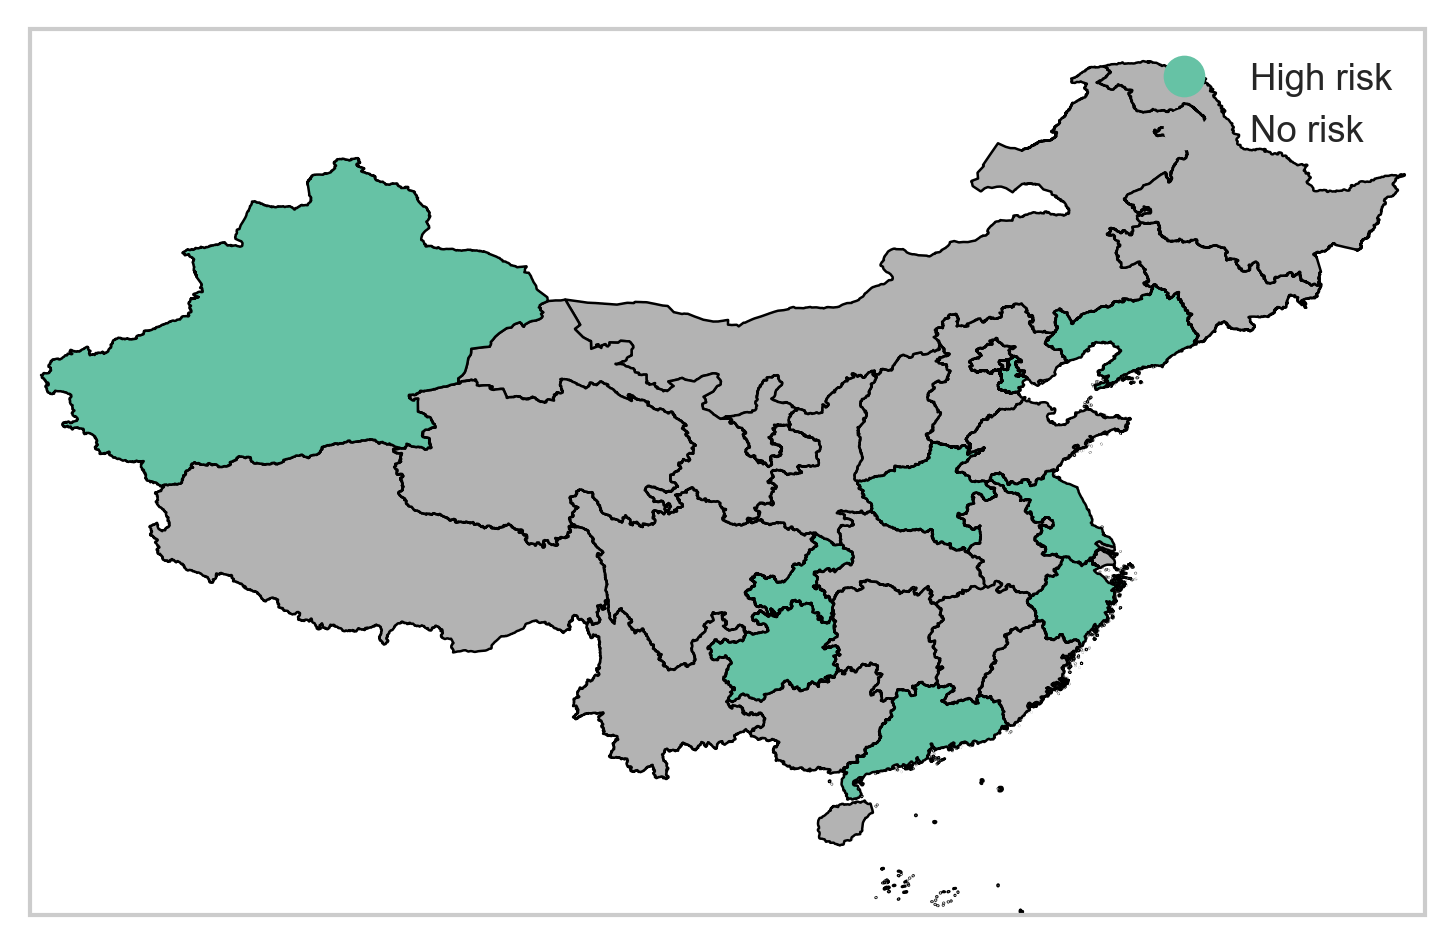

In [151]:


fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={"projection": ccrs.PlateCarree()},dpi= 300)
ax.set_extent([73, 136, 15, 55], crs=ccrs.PlateCarree())

gdf_map_plot.plot(
    column="warning_level",
    ax=ax,
    cmap="Set2",           # 离散色板，适合类别不超过 8 个
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    categorical=True,      # 关键：告诉 geopandas 这是分类变量
    missing_kwds={"color": "lightgray"},
)

plt.show()


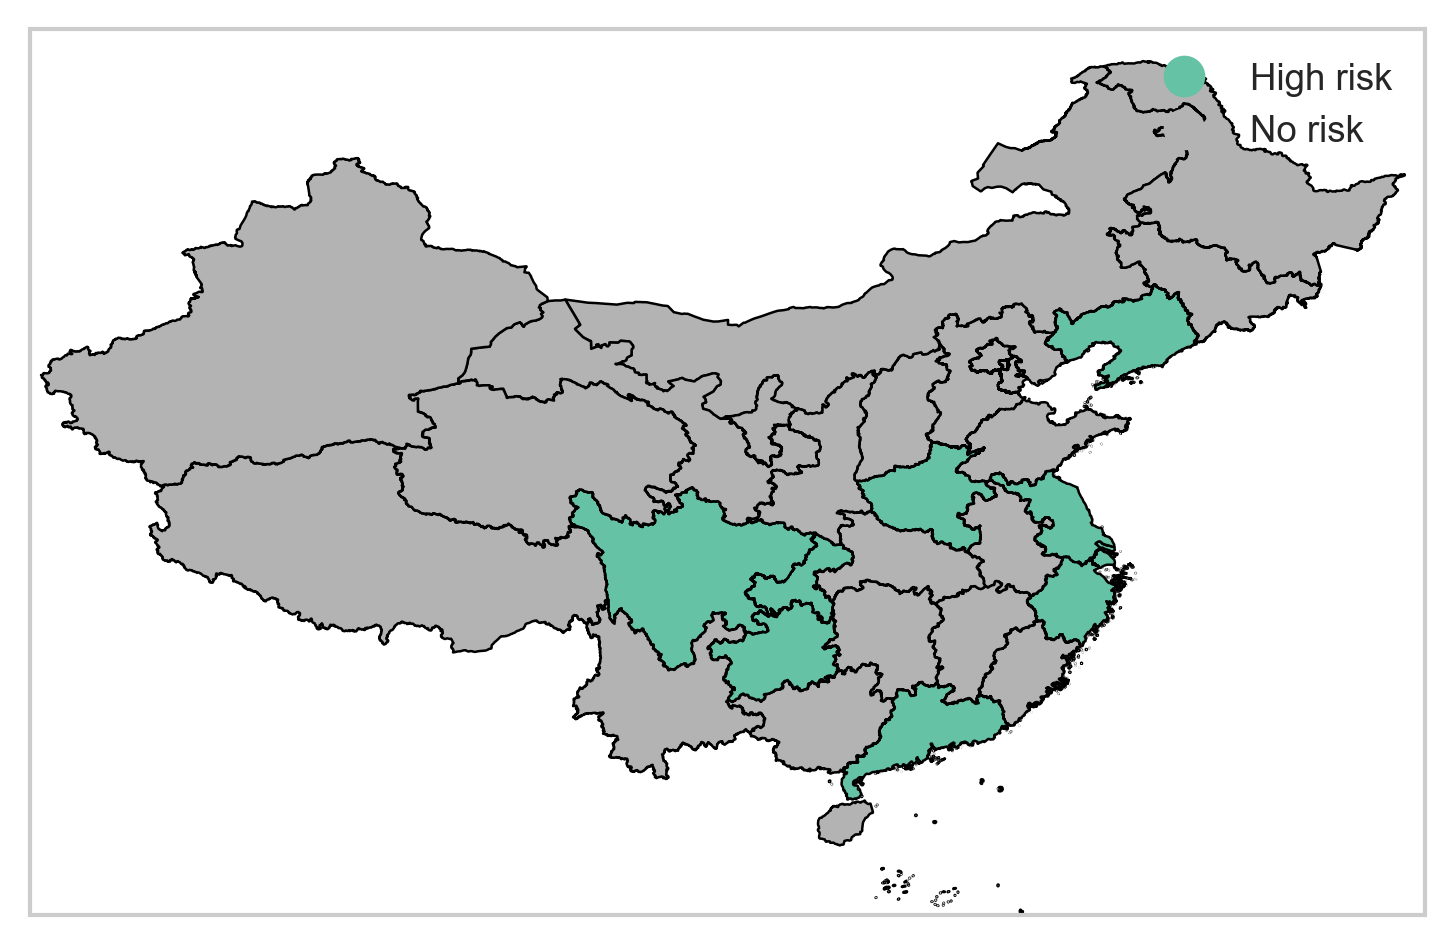

In [152]:


fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={"projection": ccrs.PlateCarree()},dpi= 300)
ax.set_extent([73, 136, 15, 55], crs=ccrs.PlateCarree())

gdf_map_plot.plot(
    column="warning_level_by_outbreak_gt_P75",
    ax=ax,
    cmap="Set2",           # 离散色板，适合类别不超过 8 个
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    categorical=True,      # 关键：告诉 geopandas 这是分类变量
    missing_kwds={"color": "lightgray"},
)

plt.show()


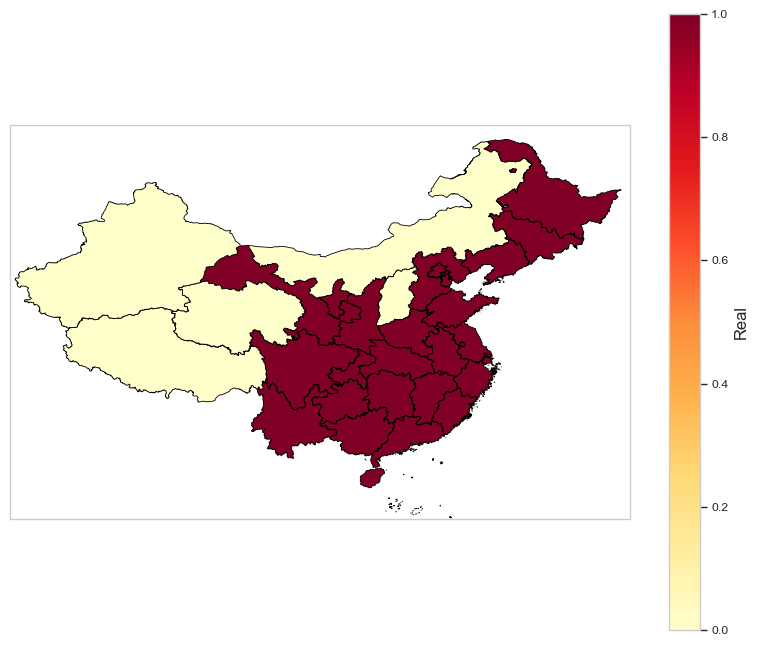

In [122]:
# 5. 用 geopandas 直接绘图（一行代码替代整个 for 循环）
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([73, 136, 15, 55], crs=ccrs.PlateCarree())

gdf_map_plot.plot(
    column="outbreak_gt_P75",   # 数值列
    ax=ax,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "Real"},
    missing_kwds={"color": "lightgray"},
)

plt.show()

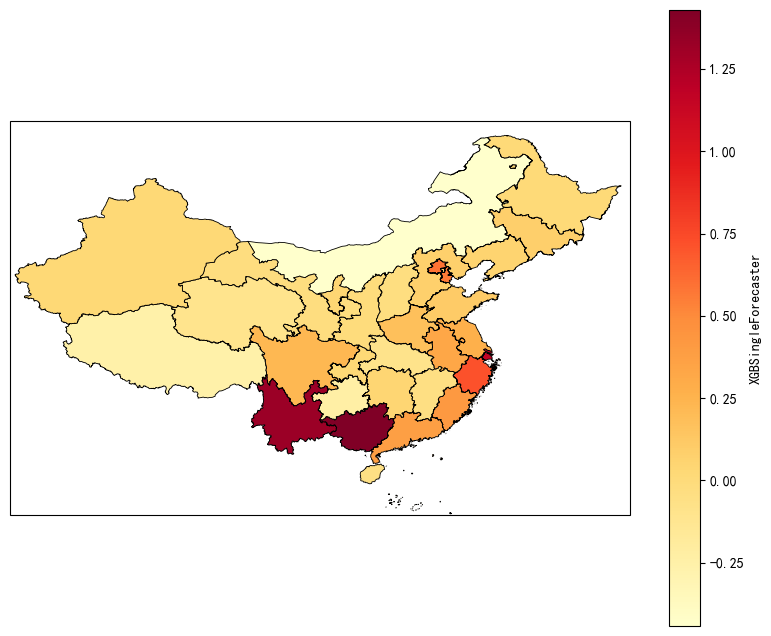

In [10]:
# 5. 用 geopandas 直接绘图（一行代码替代整个 for 循环）
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([73, 136, 15, 55], crs=ccrs.PlateCarree())

gdf_map_plot.plot(
    column="XGBSingleForecaster",   # 数值列
    ax=ax,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "XGBSingleForecaster"},
    missing_kwds={"color": "lightgray"},
)

plt.show()

In [ ]:
from shapely.geometry import shape
import geopandas as gpd
import cartopy.crs as ccrs

# 1. 从 province_maps 提取名称和几何体
records = []
for adm in province_maps:
    raw_name = get_map_name(adm)
    geom = get_map_geometry(adm)  # 你已有的函数，返回标准 shapely
    province_name = clean_province_name(raw_name) if raw_name else None

    if province_name and geom is not None:
        records.append({"province": province_name, "geometry": geom})

# 2. 转成 GeoDataFrame
gdf_map = gpd.GeoDataFrame(records, crs="EPSG:4326")

# 3. 与你的数据合并
month_data = ...  # 你的 DataFrame，包含 "City" 列
month_data["_province_clean"] = month_data["City"].apply(clean_province_name)
province_value = month_data.groupby("_province_clean")["XGBSingleForecaster"].mean()

# 4. 合并到地图 GeoDataFrame
gdf_plot = gdf_map.merge(
    province_value.reset_index(),
    left_on="province",
    right_on="_province_clean",
    how="left",
)

# 5. 用 geopandas 直接绘图（一行代码替代整个 for 循环）
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([73, 136, 15, 55], crs=ccrs.PlateCarree())

gdf_plot.plot(
    column="XGBSingleForecaster",   # 数值列
    ax=ax,
    cmap="RdYlBu_r",
    edgecolor="white",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "XGBSingleForecaster"},
    missing_kwds={"color": "lightgray"},
)

plt.show()


'City'

In [ ]:

for adm in province_maps:
    province_name = adm['province']
    geom = adm['geometry']

    print(adm, province_name)

    if province_name in province_value.index:
        value = province_value.loc[province_name]
        facecolor = colormap(norm(value))

    else:
        print(f"Not found ")
        facecolor = "lightgray"

    ax.add_geometries(
        [geom],
        crs=ccrs.PlateCarree(),
        facecolor=facecolor,
        edgecolor="white",
        linewidth=0.6
    )


In [44]:
select_df['City'] = select_df['City'].replace(PROVINCE_SHORT_NAME_MAP_TO_FULL_NAME)

In [45]:
province_value = plot_china_province_heatmap(
    select_df,
    month="2020-08-01",
    value_col="XGBSingleForecaster",
    province_col="City",
    time_col="Time"
)
province_value

{'country': '中华人民共和国', 'province': '北京市', 'city': None, 'district': None, 'level': '省', 'source': '高德', 'kind': '陆地', 'geometry': <MULTIPOLYGON (((116.784 40.031, 116.784 40.033, 116.783 40.033, 116.783 40....>, 'longitude': 116.4126254785551, 'latitude': 40.185627980321, '国家': '中华人民共和国', '省/直辖市': '北京市', '市': None, '区/县': None, '级别': '省', '来源': '高德', '类型': '陆地', '经度': 116.4126254785551, '纬度': 40.185627980321} 北京市
Not found 
{'country': '中华人民共和国', 'province': '天津市', 'city': None, 'district': None, 'level': '省', 'source': '高德', 'kind': '陆地', 'geometry': <MULTIPOLYGON (((117.841 39.406, 117.841 39.405, 117.841 39.404, 117.841 39....>, 'longitude': 117.34160050907353, 'latitude': 39.28378042076326, '国家': '中华人民共和国', '省/直辖市': '天津市', '市': None, '区/县': None, '级别': '省', '来源': '高德', '类型': '陆地', '经度': 117.34160050907353, '纬度': 39.28378042076326} 天津市
Not found 
{'country': '中华人民共和国', 'province': '河北省', 'city': None, 'district': None, 'level': '省', 'source': '高德', 'kind': '陆地', 'geometry': <MULTIPO

ValueError: Unsupported shape type <class 'cnmaps.maps.MapPolygon'>.

<Figure size 1000x800 with 2 Axes>

_province_clean
上海      38.042252
云南      41.140522
内蒙古      0.110649
北京       1.085684
吉林      -0.314485
四川      53.802528
天津      -1.371242
宁夏       0.585062
安徽      -0.993611
山东      -0.725120
山西       1.123415
广东      -2.077121
广西      46.798805
新疆       0.066153
江苏      -0.774679
江西       0.373217
河北       0.279371
河南      -0.021035
浙江       1.232662
海南       0.230015
湖北      -1.100753
湖南       0.120643
甘肃       0.544979
福建       1.045169
西藏     574.711792
贵州       2.465679
辽宁       0.484449
重庆       0.556487
陕西       4.049736
青海       0.081810
黑龙江      1.434234
Name: XGBSingleForecaster, dtype: float32

In [3]:
df_all[['Dataset', 'City']].drop_duplicates()

,Dataset,City
0,train,江西
189,train,湖南
378,train,贵州
567,train,云南
756,train,浙江
945,train,海南
1134,train,福建
1323,train,江苏
1512,train,河北
1701,train,河南


In [122]:
CityName = '湖北'
DiseaseName = 'Dengue'
plt_data = df_all.query("City==@CityName")
DatasetName = plt_data['Dataset'].unique().tolist()[0]

plot_df = plt_data.rename(columns = {"Labels":"Ground truth"}).drop(columns = ['City', 'Dataset']).melt(
    id_vars=["Time"],
    value_name='Count',
    var_name='Model'
)


In [123]:
plot_df.groupby("Model").apply(lambda x: x.assign(Count = lambda y:(y['Count'] - y['Count'].mean())/ y['Count'].std()))

Time     Count
Model                                         
AutoformerForecaster 1701 2005-01-01  0.994524
                     1702 2005-02-01 -1.349731
                     1703 2005-03-01  0.372579
                     1704 2005-04-01  0.994524
                     1705 2005-05-01 -1.355049
...                              ...       ...
XGBSingleForecaster  2263 2020-05-01 -0.373783
                     2264 2020-06-01 -0.310591
                     2265 2020-07-01 -0.293884
                     2266 2020-08-01 -0.461613
                     2267 2020-09-01 -0.369010

[2268 rows x 2 columns]